In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class FrameViT(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        
        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=16, stride=16)
        
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=8),
            num_layers=4
        )
        
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

    def forward(self, x):
        # x: [B, C, H, W]
        x = self.patch_embed(x)  # [B, D, H', W']
        
        x = x.flatten(2).transpose(1, 2)  # [B, N, D]
        
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        x = self.transformer(x)
        
        return x[:, 0]  # CLS token
    
class TemporalTransformer(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=8),
            num_layers=4
        )

    def forward(self, x):
        # x: [B, T, D]
        x = x.transpose(0, 1)  # [T, B, D]
        x = self.transformer(x)
        return x.mean(dim=0)  # [B, D]


In [3]:
class VideoEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.frame_encoder = FrameViT(embed_dim)
        self.temporal_model = TemporalTransformer(embed_dim)

    def forward(self, video):
        # video: [B, T, C, H, W]
        B, T, C, H, W = video.shape
        
        frames = video.view(B*T, C, H, W)
        
        frame_embeddings = self.frame_encoder(frames)  # [B*T, D]
        frame_embeddings = frame_embeddings.view(B, T, -1)
        
        video_embedding = self.temporal_model(frame_embeddings)
        
        return video_embedding

In [4]:
class AudioGenerator(nn.Module):
    def __init__(self, embed_dim=256, mel_bins=80, time_steps=188):
        super().__init__()
        
        self.fc = nn.Linear(embed_dim, 512)
        
        self.net = nn.Sequential(
            nn.ConvTranspose2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            
            nn.Conv2d(64, 1, 3, padding=1)
        )
        
        self.mel_bins = mel_bins
        self.time_steps = time_steps

    def forward(self, z):
        x = self.fc(z)  # [B, 512]
        
        x = x.view(x.size(0), 32, 4, 4)  # reshape to feature map
        
        x = self.net(x)  # [B, 1, H, W]
        
        # Resize to desired spectrogram size
        x = F.interpolate(x, size=(self.mel_bins, self.time_steps), mode='bilinear')
        
        return x.squeeze(1)  # [B, mel_bins, time_steps]

In [5]:
class AVFootstepModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.video_encoder = VideoEncoder()
        self.audio_generator = AudioGenerator()

    def forward(self, video):
        z = self.video_encoder(video)
        spectrogram = self.audio_generator(z)
        return spectrogram

In [6]:
def loss_fn(pred, target):
    return F.l1_loss(pred, target)

In [7]:
from torch.utils.data import Dataset, DataLoader
# data from https://andrewowens.com/vis/

import os
import torch
from torch.utils.data import Dataset
from torchcodec.decoders import VideoDecoder
import torchaudio

class AudioVideoDataset(Dataset):
    def __init__(self, root_dir, transform_video=None, transform_audio=None):
        self.root_dir = root_dir
        self.transform_video = transform_video
        self.transform_audio = transform_audio

        # collect base filenames (without extension)
        self.samples = sorted([
            f.replace(".mp4", "")
            for f in os.listdir(root_dir)
            if f.endswith(".mp4") and "thumb" not in f
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        max_audio_len = 16000 * 3  # 3 seconds
        max_frame_len = 32 * 3

        base = self.samples[idx]

        video_path = os.path.join(self.root_dir, base + ".mp4")
        audio_path = os.path.join(self.root_dir, base + ".wav")

        decoder = VideoDecoder(video_path, device="cpu")
        frames = []
        count = 0
        for frame in decoder:
            frames.append(frame)
            if count > max_frame_len:
                break
            count += 1

        video = torch.stack(frames)  # (T, C, H, W)
        video = video.float() / 255.0

        # Load audio (channels, time)
        audio, sr = torchaudio.load(audio_path)

        if self.transform_video:
            video = self.transform_video(video)

        if self.transform_audio:
            audio = self.transform_audio(audio)

        audio = audio[:, :max_audio_len]

        return {
            "video": video,
            "audio": audio,
            "sample_rate": sr,
            "id": base
        }

In [8]:
from torch.utils.data import DataLoader

dataset = AudioVideoDataset("vis-data-small/")
def collate_fn(batch):
    videos = [item["video"] for item in batch]
    audios = [item["audio"] for item in batch]

    audios = [a.mean(dim=0, keepdim=True) if a.shape[0] > 1 else a for a in audios]

    min_T = min(v.shape[0] for v in videos)
    videos = [v[:min_T] for v in videos]
    videos = torch.stack(videos)

    audios = [a.transpose(0, 1) for a in audios]  # (time, C)
    audios = torch.nn.utils.rnn.pad_sequence(audios, batch_first=True)
    audios = audios.transpose(1, 2)  # (B, C, time)

    return {
        "video": videos,
        "audio": audios
    }

dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)
for batch in dataloader:
    video = batch['video']
    target_spec = batch['audio']
    print(video.shape)
    print(target_spec.shape)

torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])
torch.Size([1, 98, 3, 256, 456])
torch.Size([1, 1, 48000])


In [9]:
model = AVFootstepModel()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_mels=80,
    n_fft=1024,
    hop_length=256
)

for batch in dataloader:
    video = batch['video']
    target_spec = batch['audio']
    target_spec = target_spec.squeeze(1)
    target_spec = mel(target_spec)
    # video = video.cuda()
    # target_spec = target_spec.cuda()
    
    pred_spec = model(video)
    print(pred_spec.shape)
    print(target_spec.shape)
    
    loss = loss_fn(pred_spec, target_spec)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print("Loss:", loss.item())

/tmp/ipykernel_87440/888580595.py:7: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_87440/888580595.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(


torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.1793794333934784
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.042476702481508255
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.08247897028923035
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.016059136018157005
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.010461916215717793
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.055919963866472244
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.03334927558898926
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.006561584305018187
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.10276325792074203
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.005080221686512232
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.004679996054619551
torch.Size([1, 80, 188])
torch.Size([1, 80, 188])
Loss: 0.009126037359237671


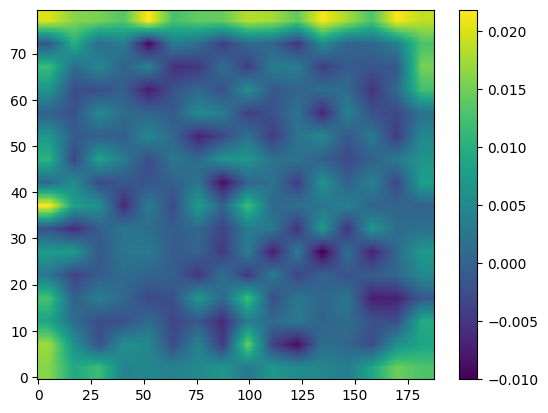

In [ ]:
import matplotlib.pyplot as plt
for batch in dataloader:
    mel_spec = model(batch['video'])
    plt.imshow(mel_spec[0].detach().cpu(), origin="lower", aspect="auto")
    plt.colorbar()
    plt.savefig("mel.png")
    plt.show()

    # torch.save({
    #     "mel": mel_spec,
    #     "hop_length": 256,
    #     "n_mels": 80
    # }, "example.pt")

In [10]:
import torchaudio

waveform = torchaudio.functional.griffinlim(
    pred_spec,
    n_fft=1024
)

TypeError: griffinlim() missing 8 required positional arguments: 'window', 'hop_length', 'win_length', 'power', 'n_iter', 'momentum', 'length', and 'rand_init'